In [1]:
import sys
sys.path.append("/home/wuhlmann/BA/repo/lamah-ce_lstm/analysis/CSA")

In [2]:
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path

from numpy.random import Generator, MT19937
from collections import Counter 
from tqdm import tqdm

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, jaccard_score
from sklearn.preprocessing import StandardScaler

#plotting
from matplotlib.patches import Patch, Polygon
import matplotlib.pyplot as plt
import seaborn as sns
from cell_state_plotters import plot_cell_state_2d, plot_cell_state_3d

In [3]:
save_fig = True 

#### Load data

In [4]:
strata_ids = pd.read_table("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/strata_ids.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [5]:
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["names"]
lamah_gdf["strata_ids"] = strata_ids["0"]
lamah_gdf.sort_index(ascending=True, inplace=True)

In [6]:
scaler = StandardScaler()

hydro_indices_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/1_attributes/Hydro_indices_1981_2017.csv")

# hy id are used to validate the clusters, which are based on the catchment attributes.
hydro_indices = pd.read_table(hydro_indices_path, header=0, sep=";")
hydro_indices.set_index("ID", inplace=True)

no_na_hy_id = hydro_indices.dropna()
numeric_hy_id = no_na_hy_id.select_dtypes(include=["number"])
scaled_hy_id = pd.DataFrame(
	scaler.fit_transform(numeric_hy_id.values),
	columns=numeric_hy_id.columns,
	index=numeric_hy_id.index
)

In [7]:
with open("/home/wuhlmann/BA/data/processed_data/evaluation/q_pred_landcover_0903_135428_domain_metrics.p", "rb") as f: 
	domain_metrics = pickle.load(f)
	
for period in domain_metrics.keys():
	
	for basin_id in domain_metrics[period].keys():
		lamah_gdf.loc[int(basin_id), "period"] = period
		lamah_gdf.loc[int(basin_id), "NSE"] = domain_metrics[period][basin_id]["1D"]["NSE"]

In [8]:
ak_clusters = pd.read_csv("/home/wuhlmann/BA/data/processed_data/CA/ak_clusters.csv", header=0, sep=";")

### MDS of cell states

In [9]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states_mds.p", "rb") as f: 
	means_mds = pickle.load(f)

print(means_mds["non_metric"][2].stress_)

0.14287285515117346


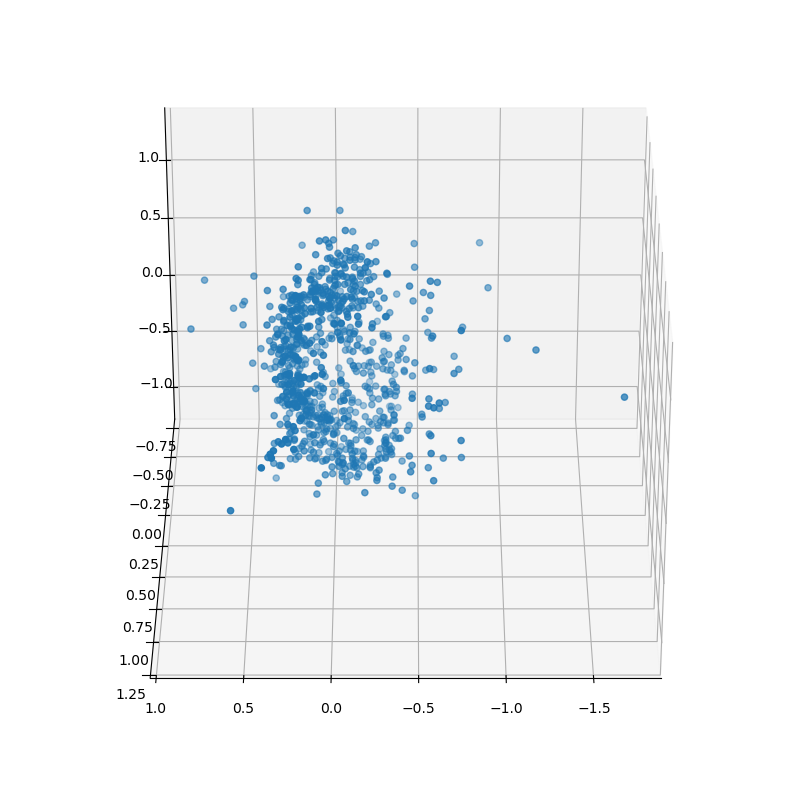

In [11]:
array = means_mds["non_metric"][3].embedding_
fig, ax = plt.subplots(1,1, figsize=(10,10), subplot_kw={"projection": "3d"})
plot_cell_state_3d(cell_state_array=array, ax=ax)
ax.view_init(azim=90)

In [10]:
array = means_mds["non_metric"][2].embedding_

In [11]:
rng_seed = 1277
rng = Generator(MT19937(rng_seed))

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:07<00:00, 12.77it/s]


Text(0.5, 1.0, 's_scores')

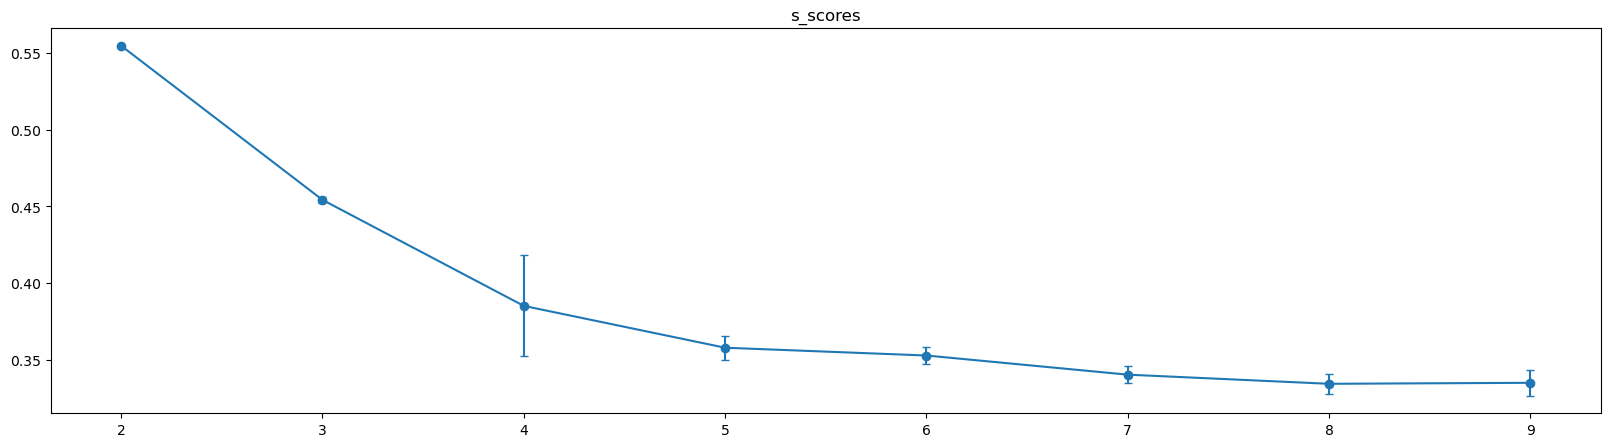

In [12]:
n_seeds = 100

seeds = list(rng.integers(0, 1000, n_seeds))
s_scores = np.zeros([n_seeds,10]) 

for i in tqdm(range(0,n_seeds)):

	seed = seeds[i]

	for k in range(2,10):

		# Test for k-means.
		labels = KMeans(k,random_state=seed).fit_predict(array)
		s_scores[i,k] = silhouette_score(array,labels) # higher is better
		
avg_s_scores = s_scores.mean(axis=0)[2:]

std_s_scores = s_scores.std(axis=0)[2:]

fig, axs = plt.subplots(1,1, figsize=(20,5))

axs.errorbar(range(2,10), avg_s_scores, yerr=std_s_scores, marker="o", capsize=3)

axs.set_title("s_scores")

#### Plot mds space

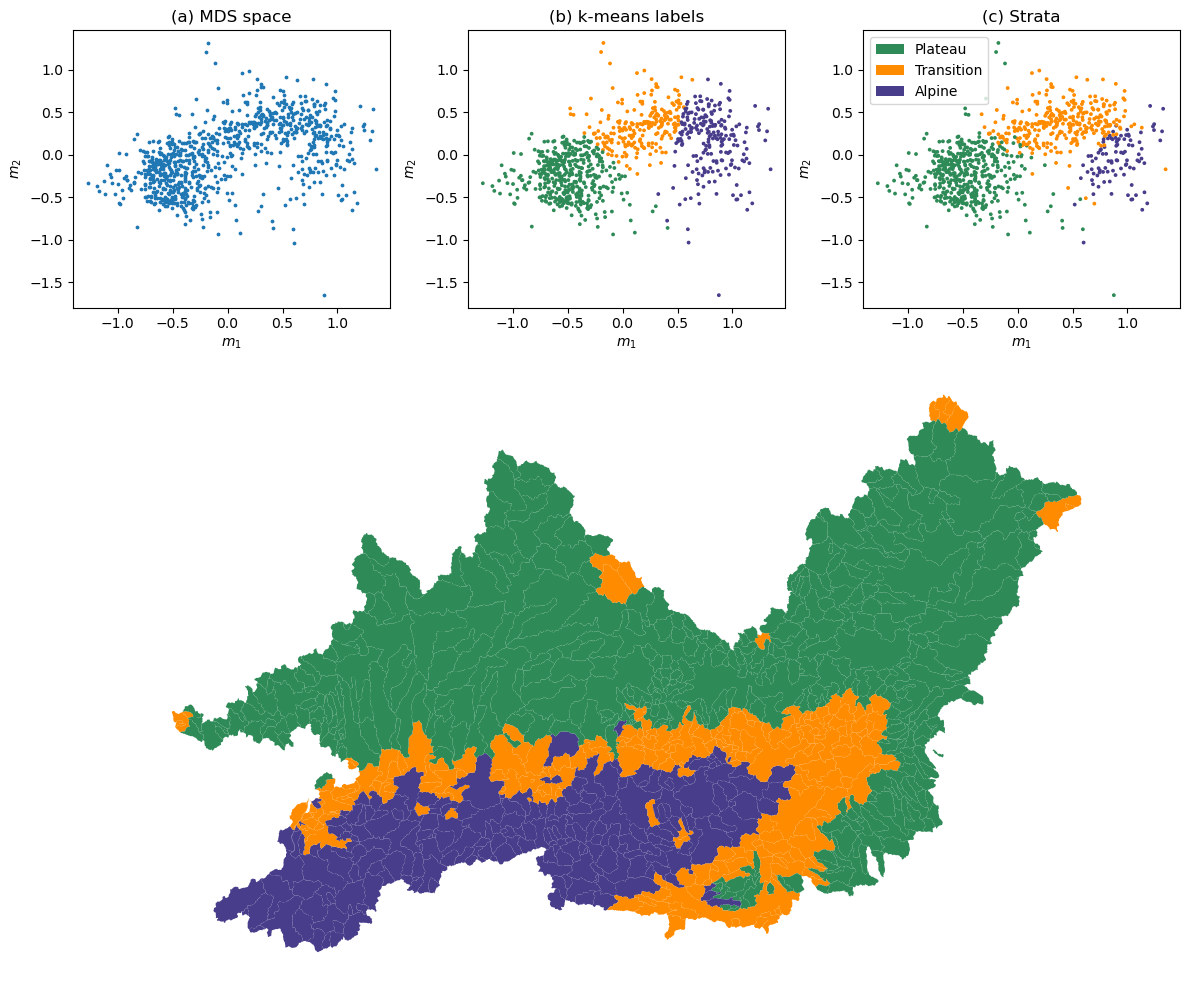

In [13]:
seed = 235 #seeds[np.where(s_scores[:,3] == Counter(s_scores[:,3]).most_common(1)[0][0])[0][0]] #235
k_means = KMeans(3, random_state=seed, max_iter=100)

fig, axs = plt.subplot_mosaic("ABC;DDD;DDD", figsize=(12,10))

cluster = k_means.fit_predict(array)

# 1. remap 
label_dict = {0: 2, 1: 0, 2: 1}
cluster_remapped = list(map(lambda x: label_dict[x], cluster))

# 2. labels
name_dict = {0: "plateau", 1: "transition", 2: "alpine"}
cluster_named = list(map(lambda x: name_dict[x], cluster_remapped))

# 3. colors
color_dict = {"plateau": "seagreen", "transition": "darkorange", "alpine": "darkslateblue"}
cluster_colors = list(map(lambda x: color_dict[x], cluster_named))
strata_colors = list(map(lambda x: color_dict[name_dict[x]], strata_ids["0"]))

# GDF
lamah_gdf["cluster"] = cluster_named

s = 3
plot_cell_state_2d(array, ax=axs["A"], title="(a) MDS space", s=s) 
plot_cell_state_2d(array, ax=axs["B"], title="(b) k-means labels", c=cluster_colors, s=s) 
plot_cell_state_2d(array, ax=axs["C"], title="(c) Strata", c=strata_colors, s=s, label=strata_colors)

legend_elements = [
    Patch(facecolor="seagreen",      label="Plateau"),
    Patch(facecolor="darkorange",    label="Transition"),
    Patch(facecolor="darkslateblue", label="Alpine"),
]
axs["C"].legend(handles=legend_elements, loc="upper left")

lamah_gdf.plot(ax=axs["D"], color=lamah_gdf["cluster"].map(color_dict))
axs["D"].axis("off")

for letter in ["A", "B", "C"]: 
    
	axs[letter].xaxis.set_label_text("$m_1$")
	axs[letter].yaxis.set_label_text("$m_2$")

plt.tight_layout()
fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/CSA/mds_centroid_cluster_map.png", dpi=300)

In [15]:
print(f"jaccard score {jaccard_score(lamah_gdf['strata'], lamah_gdf['cluster'], average=None)}")
print(f"jaccard score {jaccard_score(ak_clusters['cluster'], lamah_gdf['cluster'], average='weighted')}")

jaccard score [0.43778802 0.91921397 0.5591716 ]
jaccard score 0.8401592963125869


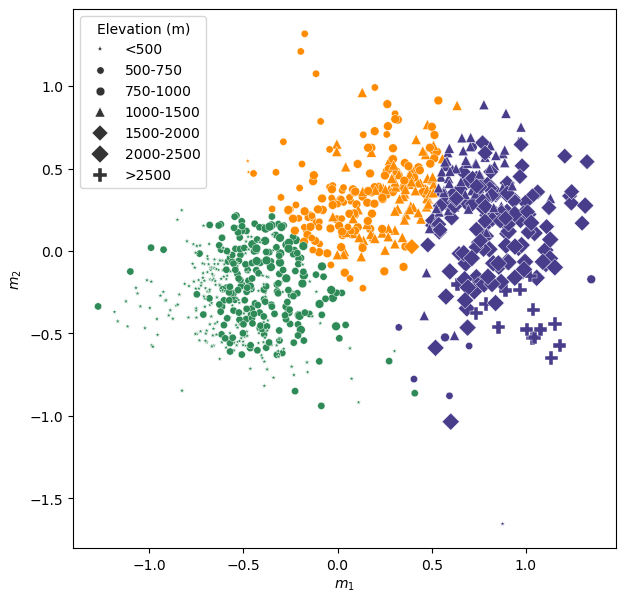

In [80]:
fig, axs = plt.subplot_mosaic("A", figsize=(7,7))


bins = [0, 500, 750, 1000, 1500, 2000, 2500, float('inf')]
labels = ["<500", "500-750", "750-1000", "1000-1500","1500-2000", "2000-2500", ">2500"]
elev_binned = pd.cut(lamah_gdf.elev_mean, bins=bins, labels=labels)

size_map = dict(zip(labels, [15, 22, 30, 45, 60, 75, 90]))
style_map = dict(zip(labels, ["*", "o", "o", "^", "D", "D", "P"]))
sizes = elev_binned.map(size_map)

sns.scatterplot(
    x=array[:,0],
    y=array[:,1], 
    style=elev_binned,
	markers=style_map,
	size=elev_binned,
	sizes=(90,15),
    ax=axs["A"],
    hue = cluster_colors, 
    palette=["darkslateblue","darkorange","seagreen"],
    legend="brief"
)

#remove hue handles 
handles, labels = axs["A"].get_legend_handles_labels()
axs["A"].legend(handles=handles[3:], labels=labels[3:], title="Elevation (m)")

# Border plateau - transition
p1 = Polygon(xy=[(-0.75,0.5),(-0.45,0.5), (0.25,-0.3),(-0.05,-0.3)], facecolor="red", edgecolor="black", alpha=0.4)
#axs["A"].add_patch(p1)
p2 = Polygon(xy=[(0.5,0.8),(0.7,0.8),(0.6,0.0), (0.4,0.0)], facecolor="yellow", edgecolor="black", alpha=0.4)
#axs["A"].add_patch(p2)

axs["A"].xaxis.set_label_text("$m_1$")
axs["A"].yaxis.set_label_text("$m_2$")

#border_basin_01_ids = lamah_gdf.index[p1.contains_points(p1.get_data_transform().transform(array))] 
#border_basin_02_ids = lamah_gdf.index[p2.contains_points(p1.get_data_transform().transform(array))] 

#lamah_gdf.plot(column="elev_mean",cmap="Grays", alpha=1,ax=axs["B"])
#lamah_gdf.loc[border_basin_01_ids, :].plot(color="red", edgecolor="black", linewidth=0.3,  ax=axs["B"])
#lamah_gdf.loc[border_basin_02_ids, :].plot(color="yellow", edgecolor="black", linewidth=0.3 , ax=axs["B"])
#axs["B"].axis("off")

#plt.tight_layout()

if save_fig: 
	fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/CSA/bordering_basins.png", dpi=300)

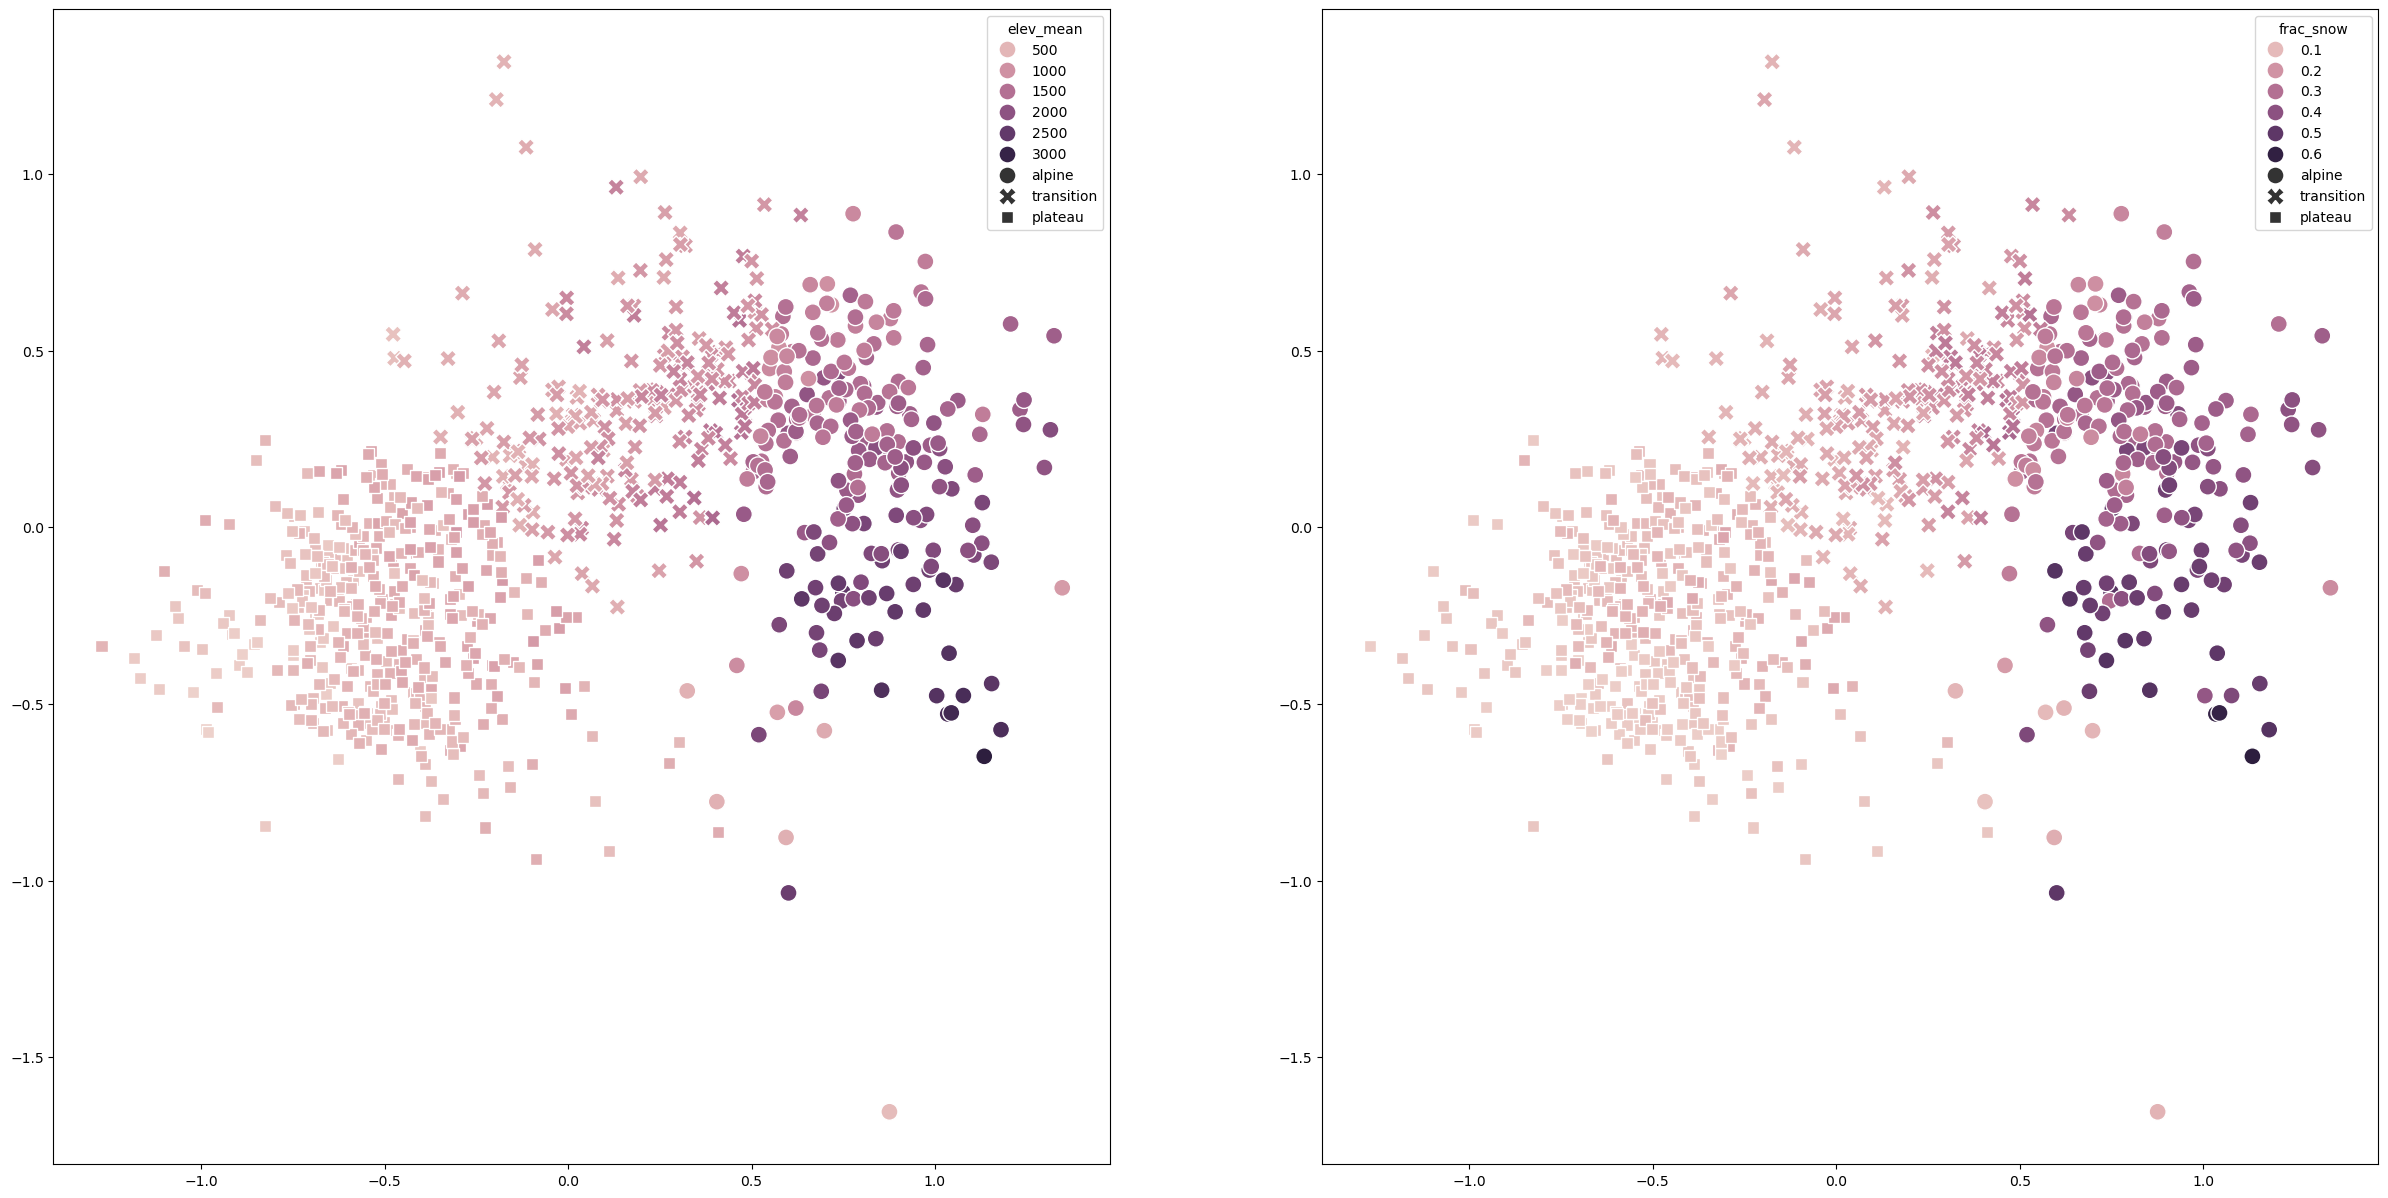

In [69]:
fig, axs = plt.subplots(1,2, figsize=(30,15))
axs = axs.ravel()

#for ax, attr in zip (axs,["lake_fra", "p_season", "elev_mean", "elev_ran", "area_calc"]): 
for ax, attr in zip (axs,["elev_mean", "frac_snow"]): 

	sns.scatterplot(
		x=array[:,0],
		y=array[:,1], 
		ax=ax, 
		hue= lamah_gdf[attr],
		style=cluster_named,
		s=150
	)

### Raw cell states

In [29]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states.p", "rb") as f: 
	raw_cell_states = pickle.load(f)

raw_cell_states = dict(sorted(raw_cell_states.items(), key=lambda item: int(item[0])))

In [30]:
r_cs_array = np.vstack([raw_cell_states[b]["c_mean"] for b in raw_cell_states.keys()])

In [31]:
from sklearn.decomposition import PCA 

pca = PCA(0.95, random_state=1277)

pca.fit(r_cs_array)

len(pca.explained_variance_ratio_)

36

100%|██████████| 100/100 [00:24<00:00,  4.06it/s]


Text(0.5, 1.0, 's_scores')

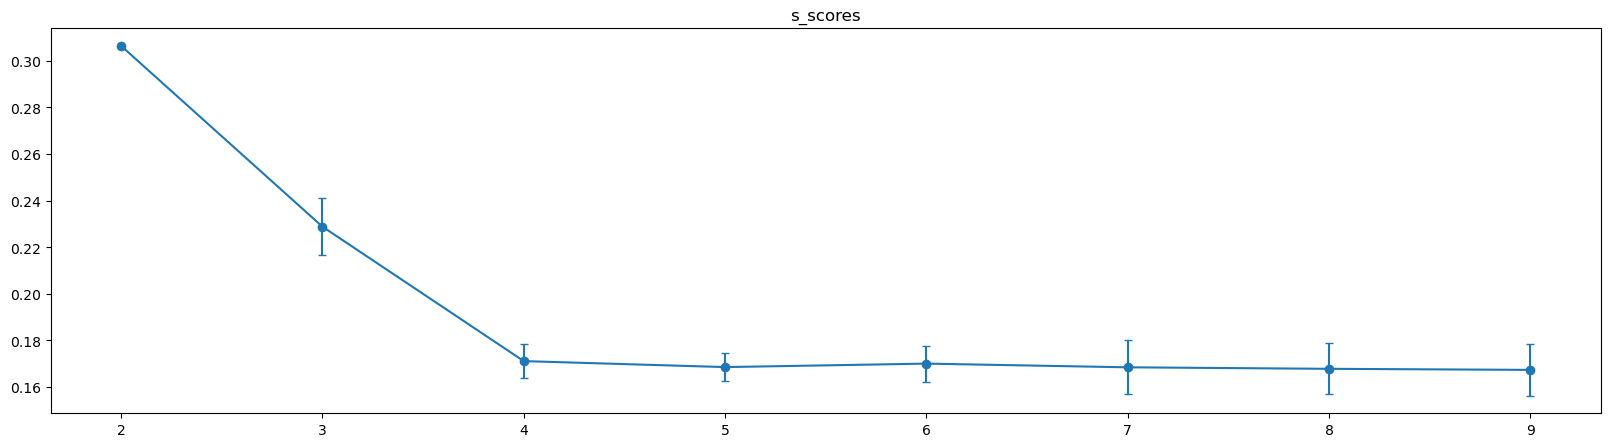

In [32]:
rng_seed = 1277
rng = Generator(MT19937(rng_seed))

n_seeds = 100

seeds = list(rng.integers(0, 1000, n_seeds))
s_scores_2 = np.zeros([n_seeds,10]) 

for i in tqdm(range(0,n_seeds)):

	seed = seeds[i]

	for k in range(2,10):

		# Test for k-means.
		labels = KMeans(k,random_state=seed).fit_predict(r_cs_array)
		s_scores_2[i,k] = silhouette_score(r_cs_array,labels) # higher is better
		
avg_s_scores_2 = s_scores_2.mean(axis=0)[2:]

std_s_scores_2 = s_scores_2.std(axis=0)[2:]

fig, axs = plt.subplots(1,1, figsize=(20,5))

axs.errorbar(range(2,10), avg_s_scores_2, yerr=std_s_scores_2, marker="o", capsize=3)

axs.set_title("s_scores")

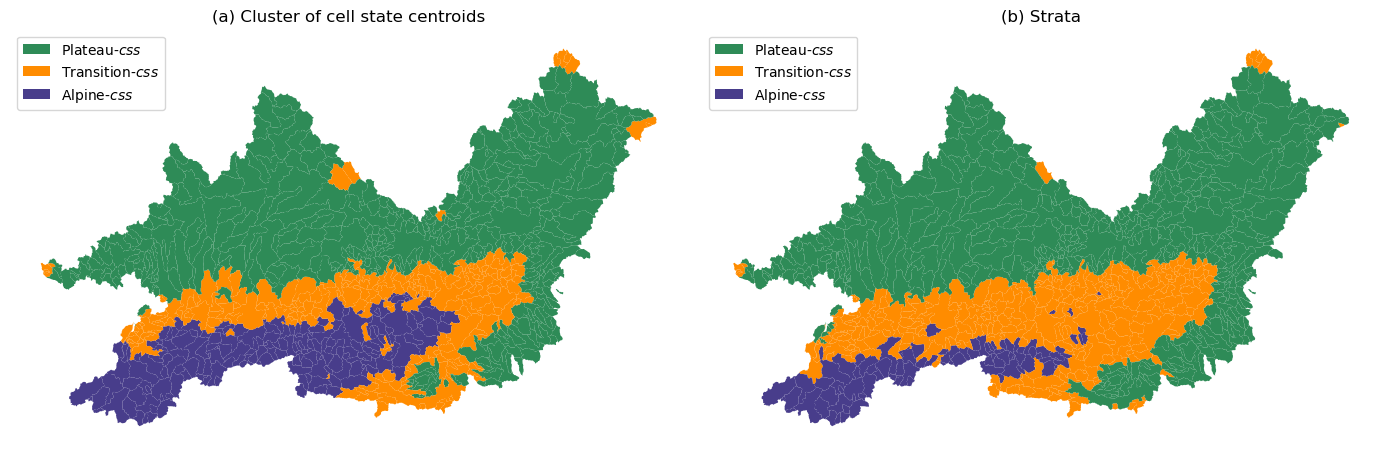

In [39]:
c = Counter(s_scores_2[:,3])

kmeans_seed = seeds[np.where(s_scores_2[:,3] == c.most_common(1)[0][0])[0][0]]

kmeans = KMeans(n_clusters=3, random_state=kmeans_seed, max_iter=100)

fig, axs = plt.subplots(1,2, figsize=(14,7))

cluster = kmeans.fit_predict(r_cs_array)

# 1. remap 
label_dict = {0: 0, 1: 2, 2: 1}
cluster_remapped = list(map(lambda x: label_dict[x], cluster))

# 2. labels
name_dict = {0: "plateau", 1: "transition", 2: "alpine"}
cluster_named = list(map(lambda x: name_dict[x], cluster_remapped))

lamah_gdf["cluster"] = cluster_named

lamah_gdf.plot(color=lamah_gdf["cluster"].map(color_dict), ax=axs[0], legend=True)
axs[0].set_title("(a) Cluster of cell state centroids")
lamah_gdf.plot(color=strata_colors, ax=axs[1], legend=True)
axs[1].set_title("(b) Strata")

axs[1].legend(handles=legend_elements, loc="upper left")
legend_elements = [
    Patch(facecolor="seagreen",      label="Plateau-$\it{css}$"),
    Patch(facecolor="darkorange",    label="Transition-$\it{css}$"),
    Patch(facecolor="darkslateblue", label="Alpine-$\it{css}$"),
]
axs[0].legend(handles=legend_elements, loc="upper left")


axs[0].set_axis_off()
axs[1].set_axis_off()

plt.tight_layout()

fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/CSA/256_centroids_cluster_map.png", dpi=300)

In [34]:
print(f"jaccard score {jaccard_score(lamah_gdf['strata'], lamah_gdf['cluster'], average=None)}")
print(f"jaccard score {jaccard_score(ak_clusters['cluster'], lamah_gdf['cluster'], average='weighted')}")

jaccard score [0.4973822  0.9279476  0.61946903]
jaccard score 0.8865879813296355
